In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jakeshbohaju/brain-tumor")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor


# 📌 Exploring Dataset Structure

Before training the CNN model, we load the dataset’s metadata CSV file to understand its structure.
This helps us inspect available columns, verify labels, and ensure the data is correctly imported before preprocessing.

In [3]:
import pandas as pd

data_dir = "/kaggle/input/brain-tumor/Brain Tumor/Brain Tumor"
csv_path = "/kaggle/input/brain-tumor/Brain Tumor.csv"
df=pd.read_csv(csv_path)
print("Dataset shape", df.shape)
df.head()

Dataset shape (3762, 15)


,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [4]:
df["Class"].value_counts()

Class
0    2079
1    1683
Name: count, dtype: int64

📌 **Loading & Preprocessing Images** 

This block iterates through each entry in the dataset CSV, loads the corresponding image file, resizes it to a fixed resolution (128×128), and stores both image data (X) and labels (y) into NumPy arrays.
This prepares the dataset for training the CNN model.

In [5]:
import os, cv2
import numpy as np

import numpy as np
img_size = 128
x=[]
y=[]

for i, row in df.iterrows():
    img_path = os.path.join(data_dir, row["Image"]+".jpg")
    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))
    x.append(img)
    y.append(row["Class"])

x = np.array(x)
y = np.array(y)

print("X shape: ", x.shape)
print("Y shape: ", y.shape)

X shape:  (3762, 128, 128, 3)
Y shape:  (3762,)


# 📌 Splitting the Dataset into Train, Validation, and Test Sets

To ensure reliable model training and evaluation, the dataset is divided into three subsets:
70% for training, 15% for validation, and 15% for testing.
We first split the data into training and temporary sets, then split the temporary set again to create balanced validation and test sets.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (2633, 128, 128, 3) (2633,)
Validation: (564, 128, 128, 3) (564,)
Test: (565, 128, 128, 3) (565,)


# 📌 Creating a Custom PyTorch Dataset Class

Since our images and labels are stored as NumPy arrays, we define a custom dataset class to integrate them smoothly with PyTorch’s DataLoader.
The class handles:

Converting NumPy images into PIL format

Applying optional data transformations (augmentation & normalization)

Returning (image, label) pairs for each index

This structure keeps the data pipeline clean and allows us to easily plug the dataset into PyTorch’s training loop.

In [7]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class ArrayImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X          
        self.y = y         
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        img = self.X[idx]
        img = Image.fromarray(img.astype(np.uint8))

        label = self.y[idx]


        if self.transform:
            img = self.transform(img)

        return img, label


import torchvision.transforms as transforms

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = ArrayImageDataset(X_train, y_train, transform=train_tf)
val_dataset   = ArrayImageDataset(X_val, y_val, transform=test_tf)
test_dataset  = ArrayImageDataset(X_test, y_test, transform=test_tf)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


# 📌 Building the CNN Model

We define a custom convolutional neural network (TumorCNN) tailored for 128×128 medical images.
The architecture consists of three convolutional blocks with batch normalization and max-pooling, followed by a fully connected classifier.
This structure captures spatial features effectively while keeping the model lightweight enough for fast training.

In [8]:
import torch
import torch.nn as nn

class TumorCNN(nn.Module):
    def __init__(self, num_classes):
        super(TumorCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),     

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),    
        )

       
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TumorCNN(num_classes=2).to(device)
print(device)
print(model)

cuda
TumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=32768, out_features=256, bias

In [11]:
import torch.optim as optim 

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# 📌 Training and Validation Loops

To train the CNN model, we implement separate functions for the training and validation phases.
The training loop performs forward passes, computes loss, backpropagates gradients, and updates model weights.
The validation loop runs in evaluation mode without gradient updates, allowing us to monitor model performance and detect overfitting.
Both loops return loss and accuracy values for each epoch.

In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [16]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/20] Train Loss: 0.1257 | Train Acc: 0.9518 | Val Loss: 0.1477 | Val Acc: 0.9344
Epoch [2/20] Train Loss: 0.1199 | Train Acc: 0.9533 | Val Loss: 0.4869 | Val Acc: 0.8085
Epoch [3/20] Train Loss: 0.1173 | Train Acc: 0.9544 | Val Loss: 0.1084 | Val Acc: 0.9521
Epoch [4/20] Train Loss: 0.0992 | Train Acc: 0.9628 | Val Loss: 0.1422 | Val Acc: 0.9415
Epoch [5/20] Train Loss: 0.0917 | Train Acc: 0.9628 | Val Loss: 0.1128 | Val Acc: 0.9557
Epoch [6/20] Train Loss: 0.0823 | Train Acc: 0.9723 | Val Loss: 0.2275 | Val Acc: 0.8989
Epoch [7/20] Train Loss: 0.0948 | Train Acc: 0.9597 | Val Loss: 0.0750 | Val Acc: 0.9699
Epoch [8/20] Train Loss: 0.0772 | Train Acc: 0.9742 | Val Loss: 0.0978 | Val Acc: 0.9628
Epoch [9/20] Train Loss: 0.0800 | Train Acc: 0.9711 | Val Loss: 0.1049 | Val Acc: 0.9592
Epoch [10/20] Train Loss: 0.0803 | Train Acc: 0.9696 | Val Loss: 0.0819 | Val Acc: 0.9716
Epoch [11/20] Train Loss: 0.0715 | Train Acc: 0.9734 | Val Loss: 0.0942 | Val Acc: 0.9681
Epoch [12/20] Train

# 📌 Testing the Model on Sample Images

To visually inspect the model’s predictions, we randomly select 10 images from the test set and display them with their predicted and true labels.
This qualitative check helps us evaluate how well the trained CNN performs on unseen data.

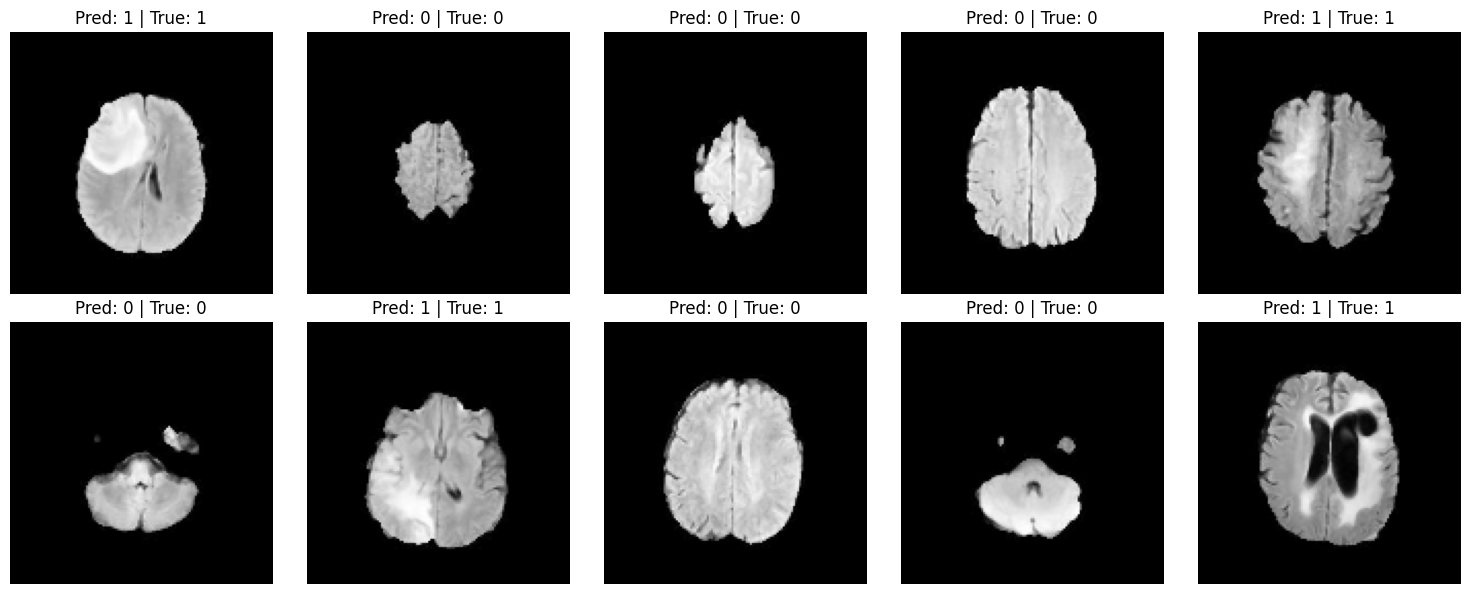

In [14]:
import matplotlib.pyplot as plt

model.eval()

indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    img = X_test[idx]
    label = y_test[idx]

    img_tensor = test_tf(Image.fromarray(img.astype(np.uint8))).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, dim=1).item()

    # plot
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred} | True: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 📌 Visualizing Training Progress

To better understand the model’s performance over time, we plot both the training and validation loss/accuracy across all epochs.
These curves allow us to monitor learning behavior, detect overfitting, and confirm whether the model is converging properly.

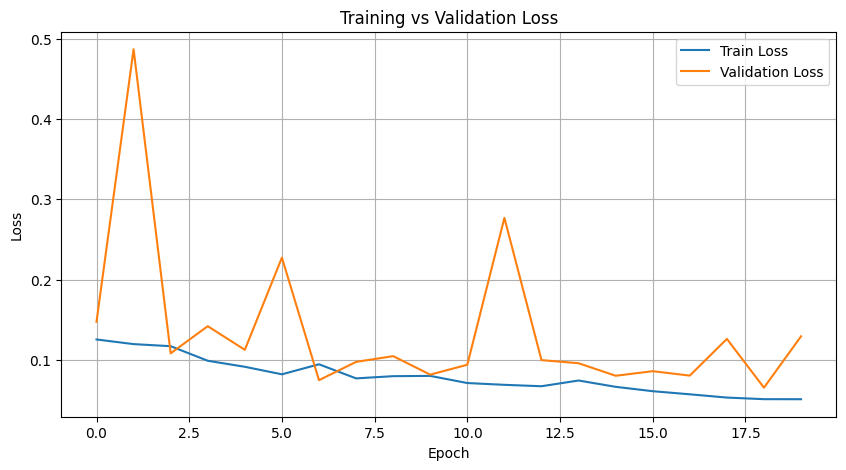

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

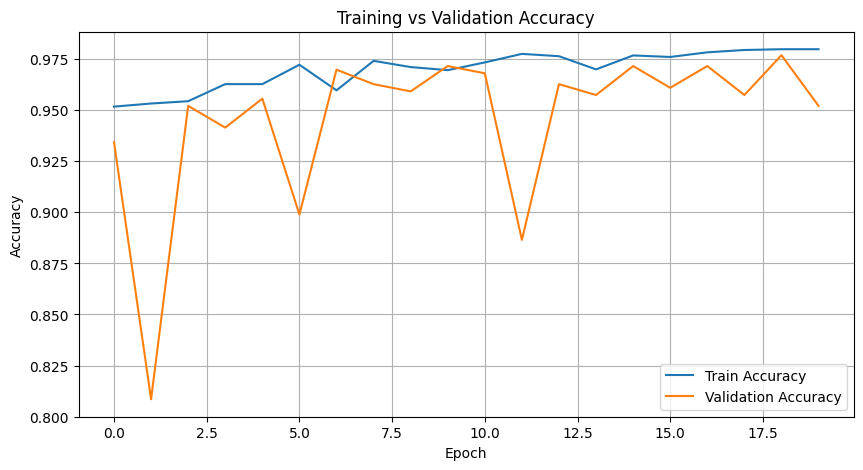

In [20]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 📌 Confusion Matrix

The confusion matrix provides a detailed breakdown of the model’s predictions for each class.
It allows us to analyze misclassifications and understand where the model performs well or struggles.

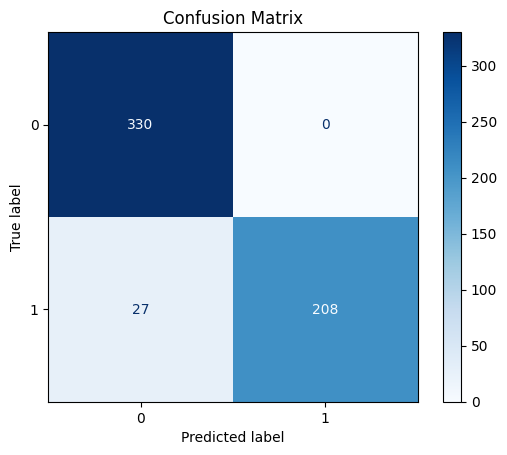

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


# 📌 Classification Report

We generate a classification report that includes precision, recall, F1-score, and support for each class.
This gives a more complete evaluation of the model’s performance beyond accuracy alone.

In [23]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(all_labels, all_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       330
           1       1.00      0.89      0.94       235

    accuracy                           0.95       565
   macro avg       0.96      0.94      0.95       565
weighted avg       0.96      0.95      0.95       565



# 📌 ROC Curve & AUC

For binary classification, the ROC curve visualizes the trade-off between true positive rate and false positive rate at different thresholds.
The AUC score summarizes the model’s ability to distinguish between classes — higher values indicate better performance.

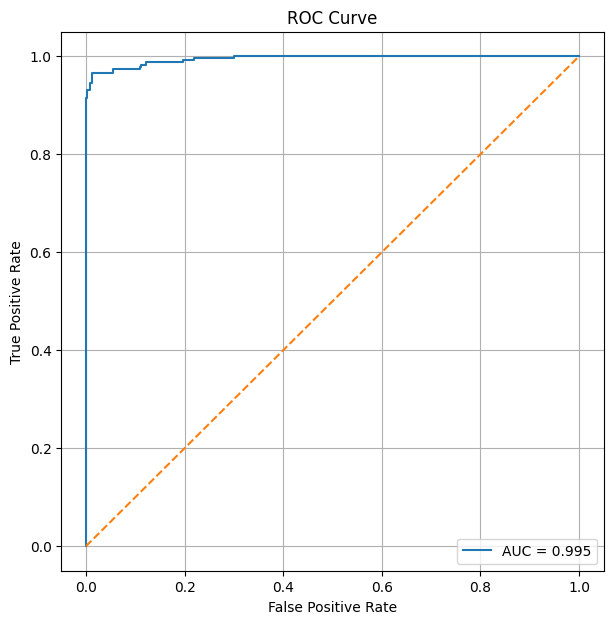

In [22]:
from sklearn.metrics import roc_curve, auc

all_probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        all_probs.extend(probs.cpu().numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
